In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import os
import numpy as np
from sklearn.model_selection import train_test_split
from torchvision import datasets

In [ ]:
BASE_PATH = "/content/drive/MyDrive/walnut_dataset_unprocessed"
SAVE_PATH = "/content/drive/MyDrive/dataset_metadata"

os.makedirs(SAVE_PATH, exist_ok=True)

In [ ]:
dataset = datasets.ImageFolder(BASE_PATH)

labels = np.array(dataset.targets)
indices = np.arange(len(dataset))

print("Total Images:", len(dataset))
print("Class Distribution:", np.bincount(labels))

Total Images: 2091
Class Distribution: [1641  450]


In [ ]:
train_idx, temp_idx = train_test_split(
    indices,
    test_size=0.30,
    stratify=labels,
    random_state=42
)

val_idx, test_idx = train_test_split(
    temp_idx,
    test_size=0.50,
    stratify=labels[temp_idx],
    random_state=42
)

In [ ]:
def check_distribution(name, idx):
    print(f"\n{name} distribution:")
    print(np.bincount(labels[idx]))

check_distribution("Train", train_idx)
check_distribution("Validation", val_idx)
check_distribution("Test", test_idx)


Train distribution:
[1148  315]

Validation distribution:
[246  68]

Test distribution:
[247  67]


In [ ]:
np.savez(
    os.path.join(SAVE_PATH, "split_indices.npz"),
    train_idx=train_idx,
    val_idx=val_idx,
    test_idx=test_idx
)

print("Dataset preparation complete. Indices saved.")

Dataset preparation complete. Indices saved.


In [ ]:
import numpy as np
from torchvision import datasets

BASE_PATH = "/content/drive/MyDrive/walnut_dataset_unprocessed"
META_PATH = "/content/drive/MyDrive/dataset_metadata/split_indices.npz"

dataset = datasets.ImageFolder(BASE_PATH)
labels = np.array(dataset.targets)

data = np.load(META_PATH)

train_idx = data["train_idx"]
val_idx   = data["val_idx"]
test_idx  = data["test_idx"]

def check_dist(name, idx):
    counts = np.bincount(labels[idx])
    print(f"{name} distribution: {counts}")

check_dist("Train", train_idx)
check_dist("Validation", val_idx)
check_dist("Test", test_idx)

Train distribution: [1148  315]
Validation distribution: [246  68]
Test distribution: [247  67]


In [ ]:
import torch
from torch.utils.data import DataLoader, Subset
from torchvision import transforms

# ==============================
# Define Transforms (ViT style)
# ==============================

train_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomRotation(10),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

test_transform = transforms.Compose([
    transforms.Resize((224,224)),
    transforms.ToTensor(),
    transforms.Normalize([0.485,0.456,0.406],
                         [0.229,0.224,0.225])
])

# ==============================
# Reload dataset with transforms
# ==============================

dataset_train = datasets.ImageFolder(BASE_PATH, transform=train_transform)
dataset_test  = datasets.ImageFolder(BASE_PATH, transform=test_transform)

# ==============================
# Create subsets using saved indices
# ==============================

train_dataset = Subset(dataset_train, train_idx)
val_dataset   = Subset(dataset_test, val_idx)
test_dataset  = Subset(dataset_test, test_idx)

# ==============================
# Create DataLoaders
# ==============================

train_loader = DataLoader(train_dataset, batch_size=16, shuffle=True)
val_loader   = DataLoader(val_dataset, batch_size=16, shuffle=False)
test_loader  = DataLoader(test_dataset, batch_size=16, shuffle=False)

print("DataLoaders ready.")

DataLoaders ready.


In [ ]:
import torch

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

Using device: cuda


In [ ]:
# Count samples per class in training set
train_labels = labels[train_idx]
class_counts = np.bincount(train_labels)

print("Training class distribution:", class_counts)

# Compute class weights
class_weights = 1.0 / class_counts
class_weights = class_weights / class_weights.sum()

print("Class weights:", class_weights)

# Move weights to correct device
class_weights_tensor = torch.tensor(class_weights, dtype=torch.float).to(device)

criterion = torch.nn.CrossEntropyLoss(weight=class_weights_tensor)

Training class distribution: [1148  315]
Class weights: [0.215311 0.784689]


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
import timm
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import classification_report, confusion_matrix
import seaborn as sns
import os
from torch.cuda.amp import GradScaler, autocast

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Using device:", device)

# =========================
# Model: ViT-B/16
# =========================
model = timm.create_model(
    "vit_base_patch16_224",
    pretrained=True,
    num_classes=2
)

# 🔥 Freeze backbone (FAST)
for param in model.parameters():
    param.requires_grad = False

# Unfreeze classifier head only
for param in model.head.parameters():
    param.requires_grad = True

model = model.to(device)

# =========================
# Optimizer (only head params)
# =========================
optimizer = optim.AdamW(model.head.parameters(), lr=1e-4, weight_decay=1e-4)

scheduler = optim.lr_scheduler.ReduceLROnPlateau(
    optimizer,
    mode='min',
    factor=0.5,
    patience=2
)

# =========================
# Training Settings
# =========================
EPOCHS = 8   # Reduced
early_stop_patience = 3
best_val_loss = float("inf")
patience_counter = 0

train_losses, val_losses = [], []
train_accs, val_accs = [], []

# Mixed precision scaler
scaler = GradScaler()

# =========================
# Training Loop
# =========================
for epoch in range(EPOCHS):

    # ---- TRAIN ----
    model.train()
    running_loss, correct, total = 0, 0, 0

    for images, labels_batch in train_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        optimizer.zero_grad()

        # 🔥 Mixed precision (FASTER)
        with autocast():
            outputs = model(images)
            loss = criterion(outputs, labels_batch)

        scaler.scale(loss).backward()
        scaler.step(optimizer)
        scaler.update()

        running_loss += loss.item()
        _, predicted = torch.max(outputs, 1)
        total += labels_batch.size(0)
        correct += predicted.eq(labels_batch).sum().item()

    train_loss = running_loss / len(train_loader)
    train_acc = 100. * correct / total

    # ---- VALIDATION ----
    model.eval()
    val_loss, correct, total = 0, 0, 0

    with torch.no_grad():
        for images, labels_batch in val_loader:
            images = images.to(device)
            labels_batch = labels_batch.to(device)

            with autocast():
                outputs = model(images)
                loss = criterion(outputs, labels_batch)

            val_loss += loss.item()
            _, predicted = torch.max(outputs, 1)
            total += labels_batch.size(0)
            correct += predicted.eq(labels_batch).sum().item()

    val_loss /= len(val_loader)
    val_acc = 100. * correct / total

    scheduler.step(val_loss)

    train_losses.append(train_loss)
    val_losses.append(val_loss)
    train_accs.append(train_acc)
    val_accs.append(val_acc)

    print(f"\nEpoch [{epoch+1}/{EPOCHS}]")
    print(f"Train Loss: {train_loss:.4f} | Train Acc: {train_acc:.2f}%")
    print(f"Val   Loss: {val_loss:.4f} | Val   Acc: {val_acc:.2f}%")

    # ---- Early Stopping ----
    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), "/content/drive/MyDrive/best_vit_model.pth")
        patience_counter = 0
    else:
        patience_counter += 1

    if patience_counter >= early_stop_patience:
        print("Early stopping triggered.")
        break

print("Training Complete.")

Using device: cuda


/usr/local/lib/python3.12/dist-packages/huggingface_hub/utils/_auth.py:94: UserWarning: 
The secret `HF_TOKEN` does not exist in your Colab secrets.
To authenticate with the Hugging Face Hub, create a token in your settings tab (https://huggingface.co/settings/tokens), set it as secret in your Google Colab and restart your session.
You will be able to reuse this secret in all of your notebooks.
Please note that authentication is recommended but still optional to access public models or datasets.
  warnings.warn(


model.safetensors:   0%|          | 0.00/346M [00:00<?, ?B/s]

/tmp/ipykernel_376/1976287079.py:58: FutureWarning: `torch.cuda.amp.GradScaler(args...)` is deprecated. Please use `torch.amp.GradScaler('cuda', args...)` instead.
  scaler = GradScaler()
/tmp/ipykernel_376/1976287079.py:76: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():
/tmp/ipykernel_376/1976287079.py:101: FutureWarning: `torch.cuda.amp.autocast(args...)` is deprecated. Please use `torch.amp.autocast('cuda', args...)` instead.
  with autocast():



Epoch [1/8]
Train Loss: 0.5437 | Train Acc: 74.91%
Val   Loss: 0.3535 | Val   Acc: 92.04%

Epoch [2/8]
Train Loss: 0.2948 | Train Acc: 94.33%
Val   Loss: 0.2111 | Val   Acc: 97.45%

Epoch [3/8]
Train Loss: 0.2054 | Train Acc: 96.51%
Val   Loss: 0.1510 | Val   Acc: 98.09%

Epoch [4/8]
Train Loss: 0.1607 | Train Acc: 97.47%
Val   Loss: 0.1195 | Val   Acc: 98.41%

Epoch [5/8]
Train Loss: 0.1285 | Train Acc: 98.29%
Val   Loss: 0.1004 | Val   Acc: 98.73%

Epoch [6/8]
Train Loss: 0.1089 | Train Acc: 98.56%
Val   Loss: 0.0869 | Val   Acc: 98.73%

Epoch [7/8]
Train Loss: 0.0966 | Train Acc: 98.84%
Val   Loss: 0.0761 | Val   Acc: 98.73%

Epoch [8/8]
Train Loss: 0.0898 | Train Acc: 98.77%
Val   Loss: 0.0690 | Val   Acc: 98.73%
Training Complete.


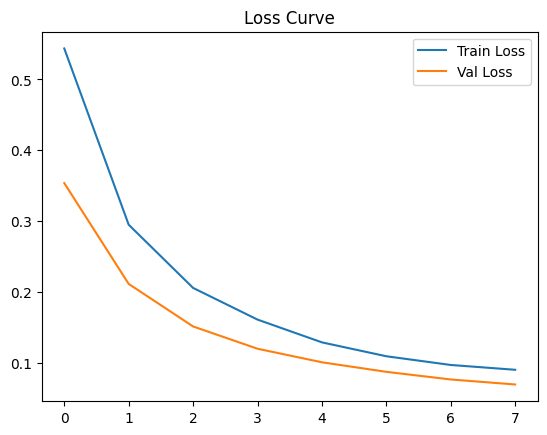

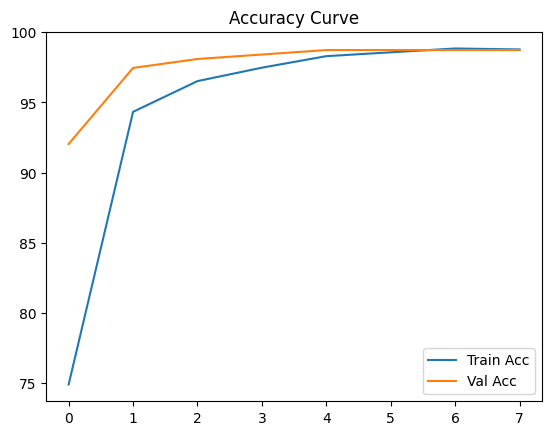

In [ ]:
plt.figure()
plt.plot(train_losses, label="Train Loss")
plt.plot(val_losses, label="Val Loss")
plt.legend()
plt.title("Loss Curve")
plt.savefig("/content/drive/MyDrive/vit_loss_curve.png")
plt.show()

plt.figure()
plt.plot(train_accs, label="Train Acc")
plt.plot(val_accs, label="Val Acc")
plt.legend()
plt.title("Accuracy Curve")
plt.savefig("/content/drive/MyDrive/vit_accuracy_curve.png")
plt.show()

In [ ]:
# Load best model
model.load_state_dict(torch.load("/content/drive/MyDrive/best_vit_model.pth"))
model.eval()

all_preds = []
all_labels = []

with torch.no_grad():
    for images, labels_batch in test_loader:
        images = images.to(device)
        labels_batch = labels_batch.to(device)

        outputs = model(images)
        _, predicted = torch.max(outputs, 1)

        all_preds.extend(predicted.cpu().numpy())
        all_labels.extend(labels_batch.cpu().numpy())

# Classification Report
report = classification_report(
    all_labels,
    all_preds,
    target_names=["Anthracnose", "Healthy"]
)

print("\nClassification Report:\n")
print(report)

# Save report
with open("/content/drive/MyDrive/vit_classification_report.txt", "w") as f:
    f.write(report)

# Confusion Matrix
cm = confusion_matrix(all_labels, all_preds)

plt.figure()
sns.heatmap(cm, annot=True, fmt="d",
            xticklabels=["Anthracnose", "Healthy"],
            yticklabels=["Anthracnose", "Healthy"])
plt.title("Confusion Matrix")
plt.savefig("/content/drive/MyDrive/vit_confusion_matrix.png")
plt.show()